In [1]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames
using CSV

In [2]:
using Revise
using Newtrinos
using Newtrinos.osc

[ Info: Precompiling Newtrinos [5b289081-bab5-45e8-97fc-86872f1653a0] (cache misses: wrong dep version loaded (2), include_dependency fhash change (2))
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0x1ddc3d8a93323544, 0x0af0afef39be1820, 0x639ac2bec2d483c1, 0xf983d3bc9216635b, 0xe2f06cb5db2a333d, 0x8149a5d8a1868b66, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())


In [3]:

osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

physics = (; osc);


experiments = (

   dayabay= Newtrinos.dayabay.configure(physics),
   gerda=Newtrinos.gerda.configure(physics)
);

par= Newtrinos.get_params(experiments)

[ Info: Loading dayabay data
[ Info: Loading Gerda data


(N = 100.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [4]:

all_priors = Newtrinos.get_priors(experiments)


vars_to_scan = ( r=31,  N=31)  

modified_priors = (
    N = par.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = par.Δm²₂₁,
    Δm²₃₁ = all_priors.Δm²₃₁,
    δCP = par.δCP,
    θ₁₂ = par.θ₁₂,
    θ₁₃ = all_priors.θ₁₃,
    θ₂₃ = par.θ₂₃
)

(N = 100.0, m₀ = Uniform{Float64}(a=1.0e-6, b=0.1), r = Uniform{Float64}(a=0.0, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = 0.8556288707523761)

In [ ]:
likelihood_NN = Newtrinos.generate_likelihood(experiments);

result_NN = Newtrinos.scan(likelihood_NN, modified_priors, vars_to_scan, par)

Progress:   3%|█▏                                       |  ETA: 5:47:24m

Indices of masses exceeding threshold: 

Progress:   3%|█▎                                       |  ETA: 5:26:51

[298, 299, 300]


Progress:   6%|██▌                                      |  ETA: 4:04:24

...

Progress:   9%|███▊                                     |  ETA: 3:33:23

Indices of masses exceeding threshold: [298, 299, 300]


Progress:  13%|█████▎                                   |  ETA: 3:12:30

Indices of masses exceeding threshold: [298, 299, 300]


Progress:  14%|█████▋                                   |  ETA: 3:09:27

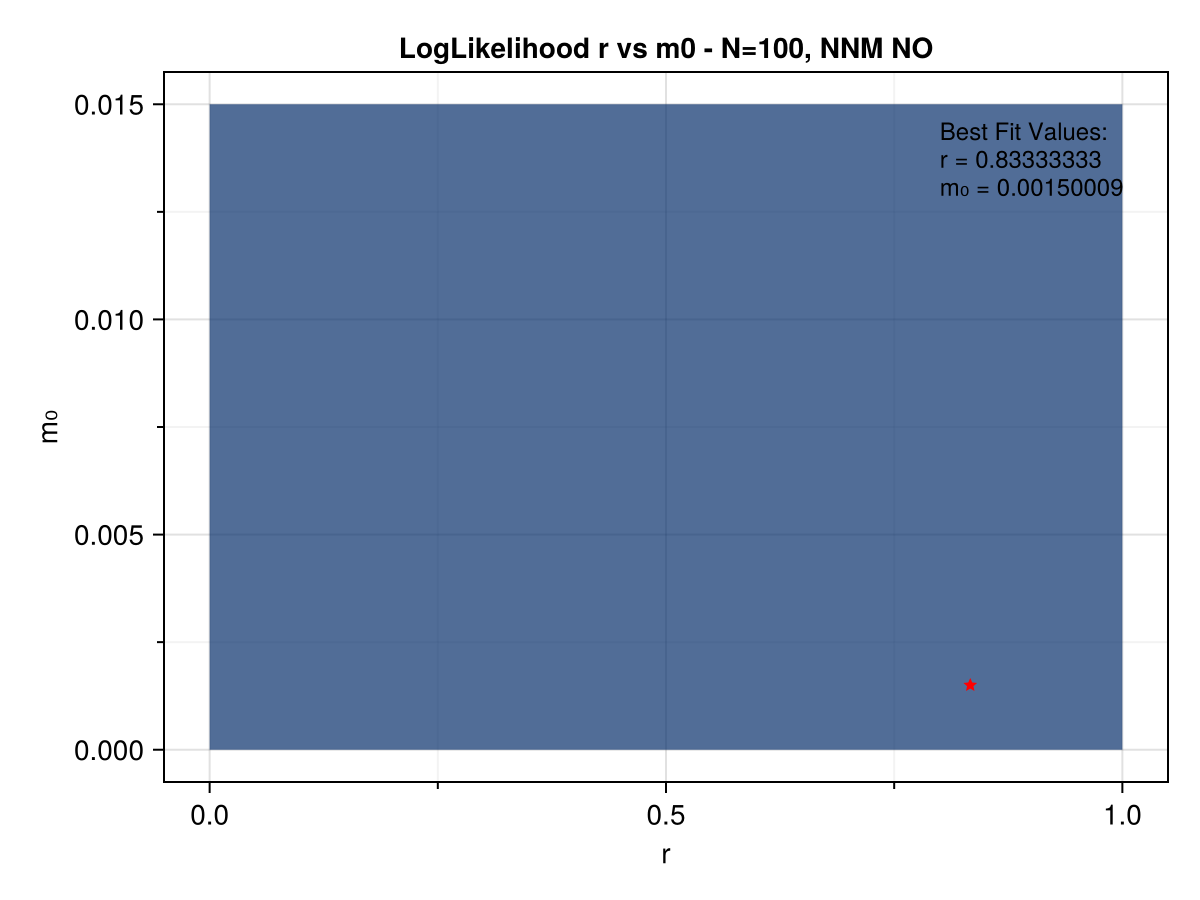

In [ ]:
#plot and save the image
using CairoMakie
img = CairoMakie.plot(result_NN; title="LogLikelihood r vs N - m0=0.01, NNM NO")
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/aug_plots/gerda/legend1000_rm0_N100_NNM_NO.png", img)